In [2]:
import pandas as pd
import numpy as np

In [5]:
# Material embeddings
materials = pd.read_csv("C:/Users/Rudradwivedi/Desktop/Matrisk AI/data/material_properties/material_embeddings.csv")

# Commodity forecasts
commodity = pd.read_csv("C:/Users/Rudradwivedi/Desktop/Matrisk AI/data/commodity_prices/copper_forecast.csv")

# Bridge risk scores
bridges = pd.read_csv("C:/Users/Rudradwivedi/Desktop/Matrisk AI/data/infrastructure_bridges/infrastructure_risk.csv")
_
# Cross-domain features
cross = pd.read_csv("C:/Users/Rudradwivedi/Desktop/Matrisk AI/data/crossdomain_features/DS4_crossdomain_features_daily.csv")

# Element prices (monthly interpolated)
elements = pd.read_csv("C:/Users/Rudradwivedi/Desktop/Matrisk AI/data/element_prices/DS5_element_prices_monthly.csv")

# Historical failures
failures = pd.read_csv("C:/Users/Rudradwivedi/Desktop/Matrisk AI/data/historical_failures/DS6_historical_failures_2000.csv")


In [9]:
print(cross.columns)
print(materials.columns)
print(bridges.columns)



Index(['date', 'commodity', 'mqi', 'supply_disruption_prob',
       'substitution_elasticity', 'green_premium_per_kg',
       'carbon_intensity_virgin', 'carbon_intensity_recycled',
       'herfindahl_index', 'mqi_5d_trend', 'mqi_21d_trend', 'mqi_63d_trend'],
      dtype='object')
Index(['material_id', 'formula', 'n_elements', 'crystal_system',
       'spacegroup_number', 'category', 'formation_energy_per_atom_ev',
       'energy_above_hull_ev', 'band_gap_ev', 'is_metal', 'bulk_modulus_gpa',
       'shear_modulus_gpa', 'poisson_ratio', 'density_g_cm3', 'nsites',
       'volume_a3', 'melting_point_k', 'is_stable', 'crystal_code',
       'crystal_system_code', 'category_code', 'material_cluster', 'embed1',
       'embed2', 'embed3'],
      dtype='object')
Index(['bridge_id', 'bridge_type', 'material', 'year_built', 'age_years',
       'design_life_years', 'location', 'corrosion_environment',
       'corrosion_rate_mm_yr', 'condition_rating', 'structurally_deficient',
       'adt', 'deck_

In [19]:
merged = cross.merge(materials, left_on="commodity", right_on="formula")
merged = bridges.merge(materials, left_on="material", right_on="formula")
merged = cross.merge(commodity.rename(columns={'predicted_close':'forecast_price'}), on="date", how="left")
merged = merged.merge(elements, on="date", how="left")



In [35]:
# Step 1: merge cross + commodity on BOTH date and commodity
final = cross.merge(
            commodity.rename(columns={'predicted_close':'forecast_price'}),
            on=["date","commodity"], how="left"
        ).merge(
            materials.assign(embedding_score=materials.filter(like='embed').mean(axis=1))[
                ['material_id','formula','embedding_score']
            ],
            left_on="commodity", right_on="formula", how="left"
        ).merge(
            bridges[['bridge_id','material','expected_cost','risk_std']],
            left_on="formula", right_on="material", how="left"
        )




In [37]:
final['matrisk_index'] = 0.4*final['embedding_score'] - 0.3*final['forecast_price'] - 0.2*final['expected_cost'] + 0.1*final.get('esg_score', 0.5)


In [39]:
final.to_csv("C:/Users/Rudradwivedi/Desktop/Matrisk AI/data/integration/matrisk_index.csv", index=False)


<Axes: title={'center': 'MatRisk Index Over Time'}, xlabel='date'>

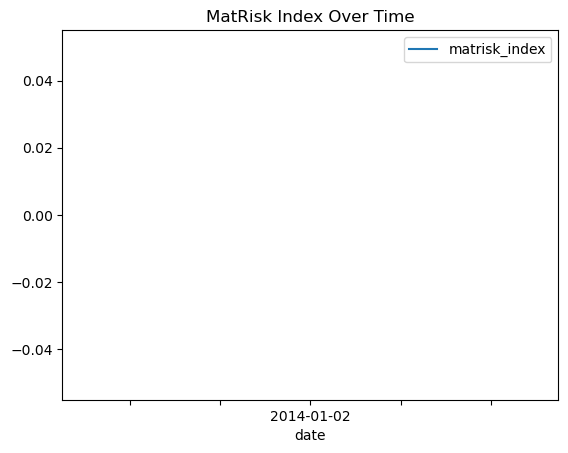

In [40]:
final.plot(x="date", y="matrisk_index", kind="line", title="MatRisk Index Over Time")
